Rasmus Svedberg | rassev-1 | rassev-1@student.ltu.se

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

In [2]:
random_state = np.random.RandomState(100)
# Create reservoir 
def create_reservoir(reservoir_size, spectral_radius):
    W = random_state.rand(reservoir_size, reservoir_size) * 2 - 1
    spectral_radius_current = compute_spectral_radius(W)
    W *= spectral_radius / spectral_radius_current
    return W

# Non zero weigths from a uniform distribution
def initialize_W(W, sparsity):
    W[random_state.rand(*W.shape) < sparsity] = 0
    return W

# Compute the spectral radius
def compute_spectral_radius(W):
    eigenvalues = np.linalg.eigvals(W)
    spectral_radius_current = np.max(np.abs(eigenvalues))
    return spectral_radius_current

In [3]:
# Create input matrix w_in
# Sample from uniform distribution
# Scale input weights by input scaling factor
def create_input_weights(input_size, reservoir_size, input_scaling):
    W_in = random_state.rand(reservoir_size, input_size) * 2 - 1
    W_in *= input_scaling
    #norm_W = normalize_input(W_in)
    return W_in

# Normalize input
def normalize_input(inp):
    inp_min = np.min(inp)
    inp_max = np.max(inp)
    inp_normalized = (inp - inp_min) / (inp_max - inp_min)
    return inp_normalized


In [4]:
# Train the ESN (only output weights)
def train_esn(W, W_in, inp, targets, washout):
    num_samples = inp.shape[0]
    reservoir_size = W.shape[0]

    states = np.zeros((num_samples - washout, reservoir_size))
    x = np.zeros((reservoir_size, 1))

    for i in range(num_samples):
        u = inp[i].reshape(-1, 1)
        x = np.tanh(np.dot(W, x) + np.dot(W_in, u))
        if i >= washout:
            states[i - washout] = x[:, 0]

    X = np.asarray(states)
    Y = targets[washout:]

    W_out, *_ = np.linalg.lstsq(X, Y, rcond=None)
    return W_out, x


Task 3.1

In [5]:
#inp_norm = normalize_input(inp)
#W_in = create_input_weights(input_size, reservoir_size, input_scaling)
#W_out = train_esn(W, W_in, inp_norm, targets, washout)


# y(n) = 0.5sin(n/4)
# Generate target signal
num_samples = 4000
def generate_target_signal(num_samples):
    n = np.arange(num_samples)
    targets = 0.5 * np.sin(n / 4)
    return targets.reshape(-1, 1)

# Split data into training and testing sets
def split_data(inp, targets):
    inp_train = inp[:3000]
    targets_train = targets[:3000]

    inp_test = inp[3000:]
    targets_test = targets[3000:]
    return inp_train, targets_train, inp_test, targets_test

# Add bias input neurons
def add_bias_input(inp):
    bias = np.ones((inp.shape[0], 1))
    inp_with_bias = np.hstack((inp, bias))
    return inp_with_bias

# Create resivoir with size 1000, spectral radius 0.8
resiovare_test = create_reservoir(1000, 0.8)

# Create input weights scale by 0.2
input_weights_test = create_input_weights(2, 1000, 0.2)

# Generate target signal and input
targets = generate_target_signal(num_samples)
inp = np.roll(targets, 1) # Teacher forcing step n-1
inp[0] = 0

# Input with bias
inp_bias_test = add_bias_input(inp)
inp_train, targets_train, inp_test, targets_test = split_data(inp_bias_test, targets)

In [6]:
# State of reservoir for training sequnce
W_out, last = train_esn(resiovare_test, input_weights_test, inp_train, targets_train, washout = 1000)

# Use trained output weights to predict test sequence
def predict_esn(W, W_in, W_out, last, inp, steps):
    resiovare_size = W.shape[0]
    y_prev = float(inp)
    x = last.copy().reshape(resiovare_size, 1)
    preds = np.zeros((steps, 1))

    for i in range(steps):
        u = np.array([[y_prev], [1]])
        x = np.tanh(np.dot(W, x) + np.dot(W_in, u))

        y = float(x.T.dot(W_out)[0, 0])
        preds[i, 0] = float(y)
        y_prev = y

    return preds


init_output = targets_train[-1, 0]


In [7]:
random_state.seed(1)

W1 = create_reservoir(1000, 0.8)
W_in1 = create_input_weights(2, 1000, 0.2)
W_out1, last_state1 = train_esn(W1, W_in1, inp_train, targets_train, 1000)

init_output1 = targets_train[-1, 0]

preds1 = predict_esn(W1, W_in1, W_out1, last_state1, init_output1, 1000)


In [8]:
random_state.seed(2)

W2 = create_reservoir(1000, 0.8)
W_in2 = create_input_weights(2, 1000, 0.2)
W_out2, last_state2 = train_esn(W2, W_in2, inp_train, targets_train, 1000)

init_output2 = targets_train[-1, 0]

preds2 = predict_esn(W2, W_in2, W_out2, last_state2, init_output2, 1000)

In [9]:
random_state.seed(3)

W3 = create_reservoir(1000, 0.8)
W_in3 = create_input_weights(2, 1000, 0.2)
W_out3, last_state3 = train_esn(W3, W_in3, inp_train, targets_train, 1000)

init_output3 = targets_train[-1, 0]

preds3 = predict_esn(W3, W_in3, W_out3, last_state3, init_output3, 1000)

In [10]:
random_state.seed(4)

W4 = create_reservoir(1000, 0.8)
W_in4 = create_input_weights(2, 1000, 0.2)
W_out4, last_state4 = train_esn(W4, W_in4, inp_train, targets_train, 1000)

init_output4 = targets_train[-1, 0]

preds4 = predict_esn(W4, W_in4, W_out4, last_state4, init_output4, 1000)

In [11]:
random_state.seed(5)

W5 = create_reservoir(1000, 0.8)
W_in5 = create_input_weights(2, 1000, 0.2)
W_out5, last_state5 = train_esn(W5, W_in5, inp_train, targets_train, 1000)

init_output5 = targets_train[-1, 0]

preds5 = predict_esn(W5, W_in5, W_out5, last_state5, init_output5, 1000)

In [12]:
random_state.seed(6)

W6 = create_reservoir(1000, 0.8)
W_in6 = create_input_weights(2, 1000, 0.2)
W_out6, last_state6 = train_esn(W6, W_in6, inp_train, targets_train, 1000)

init_output6 = targets_train[-1, 0]

preds6 = predict_esn(W6, W_in6, W_out6, last_state6, init_output6, 1000)

In [13]:
random_state.seed(7)

W7 = create_reservoir(1000, 0.8)
W_in7 = create_input_weights(2, 1000, 0.2)
W_out7, last_state7 = train_esn(W7, W_in7, inp_train, targets_train, 1000)

init_output7 = targets_train[-1, 0]

preds7 = predict_esn(W7, W_in7, W_out7, last_state7, init_output7, 1000)

In [14]:
random_state.seed(8)

W8 = create_reservoir(1000, 0.8)
W_in8= create_input_weights(2, 1000, 0.2)
W_out8, last_state8 = train_esn(W8, W_in8, inp_train, targets_train, 1000)

init_output8 = targets_train[-1, 0]

preds8= predict_esn(W8, W_in8, W_out8, last_state8, init_output8, 1000)

In [15]:
random_state.seed(9)

W9 = create_reservoir(1000, 0.8)
W_in9= create_input_weights(2, 1000, 0.2)
W_out9, last_state9 = train_esn(W9, W_in9, inp_train, targets_train, 1000)

init_output9 = targets_train[-1, 0]

preds9= predict_esn(W9, W_in9, W_out9, last_state9, init_output9, 1000)

In [16]:
random_state.seed(10)

W10 = create_reservoir(1000, 0.8)
W_in10 = create_input_weights(2, 1000, 0.2)
W_out10, last_state10 = train_esn(W10, W_in10, inp_train, targets_train, 1000)

init_output10 = targets_train[-1, 0]

preds10 = predict_esn(W10, W_in10, W_out10, last_state10, init_output10, 1000)

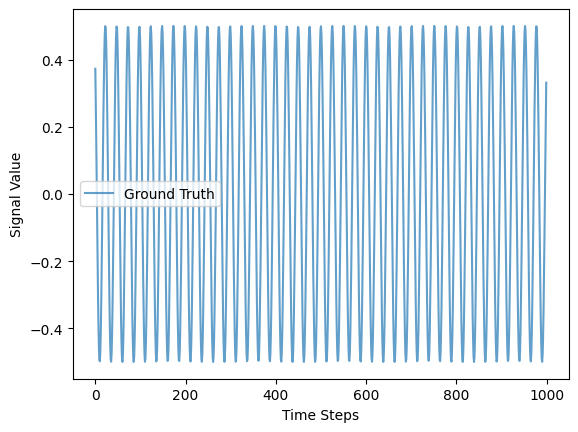

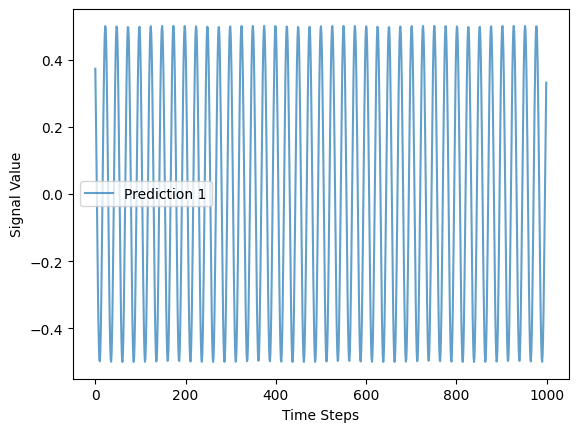

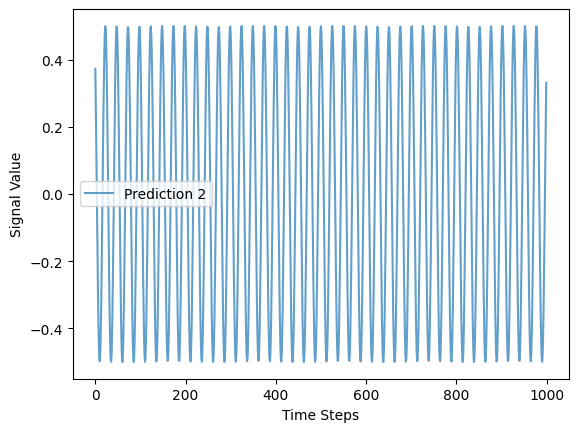

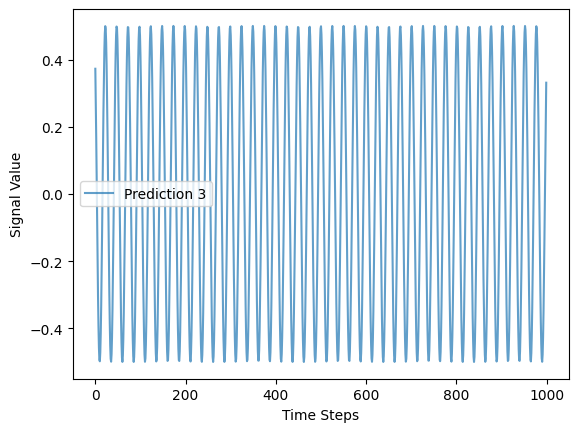

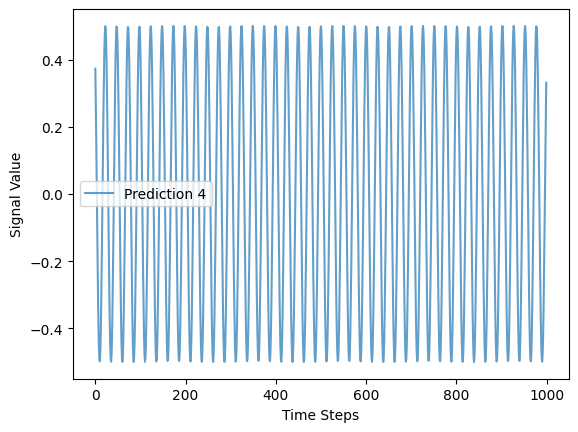

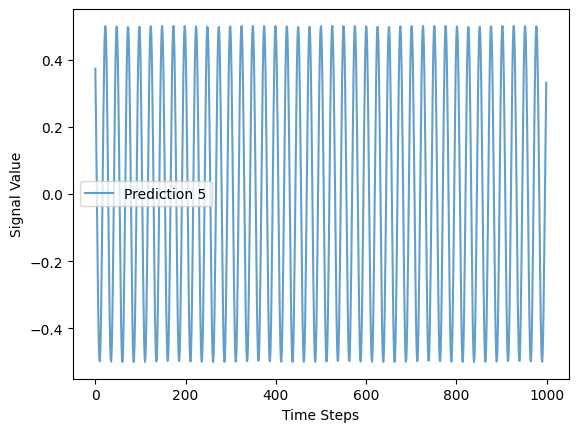

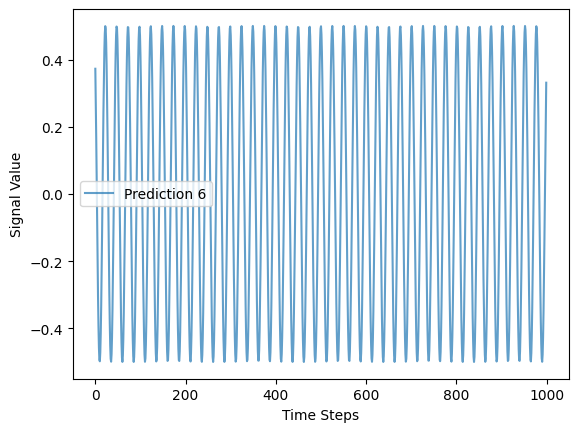

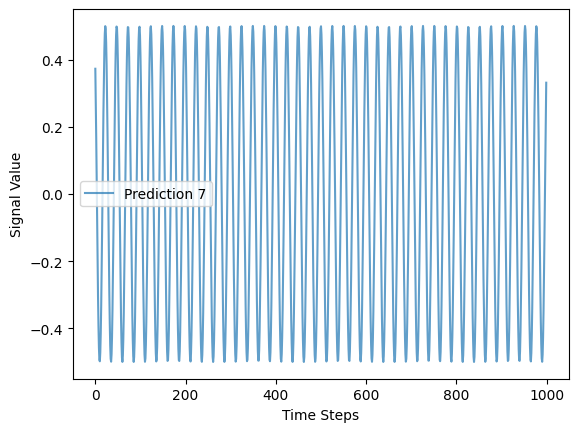

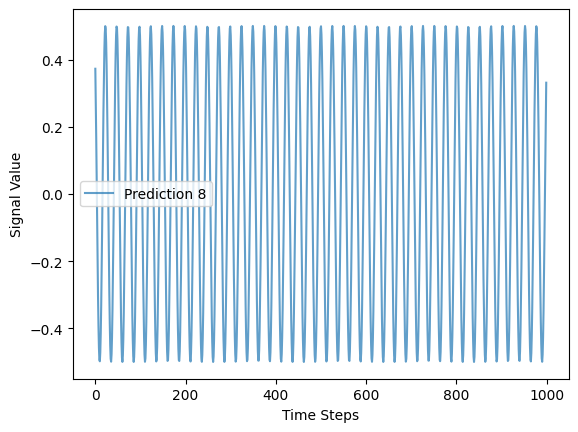

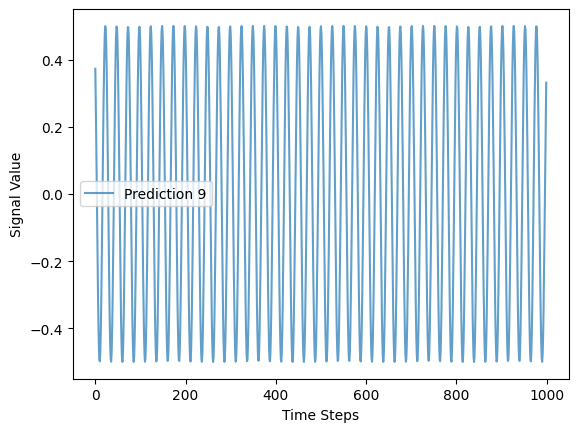

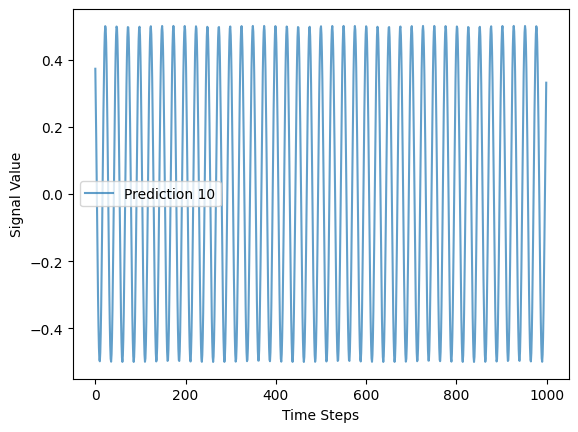

In [17]:
# Plot all predictions vs ground truth
plt.plot(targets_test, label='Ground Truth', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()
plt.plot(preds1, label='Prediction 1', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()
plt.plot(preds2, label='Prediction 2', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()
plt.plot(preds3, label='Prediction 3', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()
plt.plot(preds4, label='Prediction 4', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()
plt.plot(preds5, label='Prediction 5', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()
plt.plot(preds6, label='Prediction 6', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()
plt.plot(preds7, label='Prediction 7', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()
plt.plot(preds8, label='Prediction 8', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()
plt.plot(preds9, label='Prediction 9', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()
plt.plot(preds10, label='Prediction 10', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()

Task 3.2

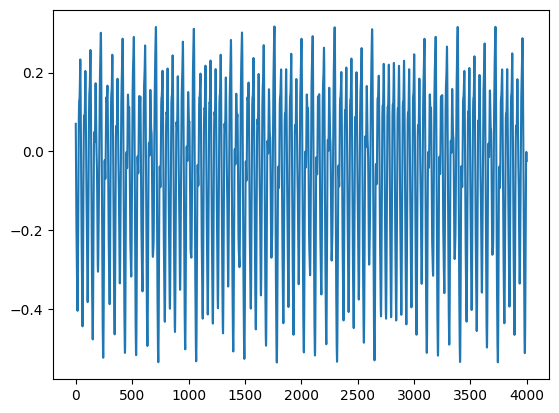

In [18]:
# Whats was given to generate the data
import numpy as np
import matplotlib.pyplot as plt

# check for intuition at http://users.fs.cvut.cz/ivo.bukovsky/PVVR/prace_studentu/Mackey_Glass_time_series_prediction_Fuzzy_Lookup.pdf

def mackey_glass(tau, length):
    betta=0.2
    gamma = 0.1 
    a=10
    delay=100 # will cut these initial steps
    
    y=np.random.rand(tau) # random intial values between 0 and 1
    # Euler's method to solve the differential equation
    for t in range(tau-1, length+delay+tau-1):
        current= y[t] + ( betta * y[t-(tau-1)]   / ( 1 + np.power(y[t-(tau-1)], a)   )  ) - gamma*y[t]   
        y=np.append(y, current)
    
    y=y-1 # get rid of mean
    y=np.tanh(y) # squeze with tanh    
    
    return y[tau+delay:length+delay+tau] # return the last length elements


length=4000 # duration of the series
tau=17 # delay in the equation

y=mackey_glass(tau, length)
#plot generated time-series
plt.plot(y)
plt.show()

In [ ]:
def train_esn_mg(W, W_in, inp, targets, washout):
    num_samples = inp.shape[0]
    reservoir_size = W.shape[0]

    states = np.zeros((num_samples - washout, reservoir_size))
    x = np.zeros((reservoir_size, 1))

    for i in range(num_samples):
        u = inp[i].reshape(-1, 1)
        x = np.tanh(np.dot(W, x) + np.dot(W_in, u))
        if i >= washout:
            states[i - washout] = x[:, 0]

    X = np.asarray(states)
    Y = targets[washout:]

    # Had to add ridge regression to make it work (w_out_mg exploded otherwise)
    N = X.shape[1] 
    sqrt_ridge = np.sqrt(1e-3)
    X_aug = np.vstack([X, sqrt_ridge * np.eye(N)])
    Y_aug = np.vstack([Y, np.zeros((N, Y.shape[1]))])
    W_out, *_ = np.linalg.lstsq(X_aug, Y_aug, rcond=None)

    return W_out, x

In [58]:
targets_mg = y.reshape(-1, 1)

inp_mg = np.roll(targets_mg, 1)
inp_mg[0] = 0

inp_mg_bias = add_bias_input(inp_mg)

inp_mg_train, targets_mg_train, inp_mg_test, targets_mg_test = split_data(inp_mg_bias, targets_mg)


In [59]:
W_mg = create_reservoir(1000, 0.8)
W_in_mg = create_input_weights(2, 1000, 0.2)

W_out_mg, last_state_mg = train_esn_mg(W_mg, W_in_mg, inp_mg_train, targets_mg_train, 1000)

In [60]:
init_mg_output = targets_mg_train[-1, 0]
preds_mg = predict_esn(W_mg, W_in_mg, W_out_mg, last_state_mg, init_mg_output, 1000)


In [61]:
random_state.seed(1)

W_mg1 = create_reservoir(1000, 0.8)
W_in_mg1 = create_input_weights(2, 1000, 0.2)
W_out_mg1, last_state_mg1 = train_esn_mg(W_mg1, W_in_mg1, inp_mg_train, targets_mg_train, 1000)

init_mg_output1 = targets_mg_train[-1, 0]

preds_mg1 = predict_esn(W_mg1, W_in_mg1, W_out_mg1, last_state_mg1, init_mg_output1, 1000)

print("max |W_out|:", np.max(np.abs(W_out)))
print("max |W_out|:", np.max(np.abs(W_out_mg)))



max |W_out|: 0.05201196873201544
max |W_out|: 0.1808331096817867


In [62]:
random_state.seed(2)

W_mg2 = create_reservoir(1000, 0.8)
W_in_mg2 = create_input_weights(2, 1000, 0.2)
W_out_mg2, last_state_mg2 = train_esn_mg(W_mg2, W_in_mg2, inp_mg_train, targets_mg_train, 1000)

init_output_mg2 = targets_mg_train[-1, 0]

preds_mg2 = predict_esn(W_mg2, W_in_mg2, W_out_mg2, last_state_mg2, init_output_mg2, 1000)

In [63]:
random_state.seed(3)

W_mg3 = create_reservoir(1000, 0.8)
W_in_mg3 = create_input_weights(2, 1000, 0.2)
W_out_mg3, last_state_mg3 = train_esn_mg(W_mg3, W_in_mg3, inp_mg_train, targets_mg_train, 1000)

init_output_mg3 = targets_mg_train[-1, 0]

preds_mg3 = predict_esn(W_mg3, W_in_mg3, W_out_mg3, last_state_mg3, init_output_mg3, 1000)

In [64]:

random_state.seed(4)

W_mg4 = create_reservoir(1000, 0.8)
W_in_mg4 = create_input_weights(2, 1000, 0.2)
W_out_mg4, last_state_mg4 = train_esn_mg(W_mg4, W_in_mg4, inp_mg_train, targets_mg_train, 1000)

init_output_mg4 = targets_mg_train[-1, 0]

preds_mg4 = predict_esn(W_mg4, W_in_mg4, W_out_mg4, last_state_mg4, init_output_mg4, 1000)

In [65]:
random_state.seed(5)

W_mg5 = create_reservoir(1000, 0.8)
W_in_mg5 = create_input_weights(2, 1000, 0.2)
W_out_mg5, last_state_mg5 = train_esn_mg(W_mg5, W_in_mg5, inp_mg_train, targets_mg_train, 1000)

init_output_mg5 = targets_mg_train[-1, 0]

preds_mg5 = predict_esn(W_mg5, W_in_mg5, W_out_mg5, last_state_mg5, init_output_mg5, 1000)

In [66]:
random_state.seed(6)

W_mg6 = create_reservoir(1000, 0.8)
W_in_mg6 = create_input_weights(2, 1000, 0.2)
W_out_mg6, last_state_mg6 = train_esn_mg(W_mg6, W_in_mg6, inp_mg_train, targets_mg_train, 1000)

init_output_mg6 = targets_mg_train[-1, 0]

preds_mg6 = predict_esn(W_mg6, W_in_mg6, W_out_mg6, last_state_mg6, init_output_mg6, 1000)

In [67]:
random_state.seed(7)

W_mg7 = create_reservoir(1000, 0.8)
W_in_mg7 = create_input_weights(2, 1000, 0.2)
W_out_mg7, last_state_mg7 = train_esn_mg(W_mg7, W_in_mg7, inp_mg_train, targets_mg_train, 1000)

init_output_mg7 = targets_mg_train[-1, 0]

preds_mg7 = predict_esn(W_mg7, W_in_mg7, W_out_mg7, last_state_mg7, init_output_mg7, 1000)

In [68]:
random_state.seed(8)

W_mg8 = create_reservoir(1000, 0.8)
W_in_mg8= create_input_weights(2, 1000, 0.2)
W_out_mg8, last_state_mg8 = train_esn_mg(W_mg8, W_in_mg8, inp_mg_train, targets_mg_train, 1000)

init_output_mg8 = targets_mg_train[-1, 0]

preds_mg8= predict_esn(W_mg8, W_in_mg8, W_out_mg8, last_state_mg8, init_output_mg8, 1000)

In [69]:
random_state.seed(9)

W_mg9 = create_reservoir(1000, 0.8)
W_in_mg9= create_input_weights(2, 1000, 0.2)
W_out_mg9, last_state_mg9 = train_esn_mg(W_mg9, W_in_mg9, inp_mg_train, targets_mg_train, 1000)

init_output_mg9 = targets_mg_train[-1, 0]

preds_mg9= predict_esn(W_mg9, W_in_mg9, W_out_mg9, last_state_mg9, init_output_mg9, 1000)

In [70]:
random_state.seed(10)

W_mg10 = create_reservoir(1000, 0.8)
W_in_mg10 = create_input_weights(2, 1000, 0.2)
W_out_mg10, last_state_mg10 = train_esn_mg(W_mg10, W_in_mg10, inp_mg_train, targets_mg_train, 1000)

init_output_mg10 = targets_mg_train[-1, 0]

preds_mg10 = predict_esn(W_mg10, W_in_mg10, W_out_mg10, last_state_mg10, init_output_mg10, 1000)

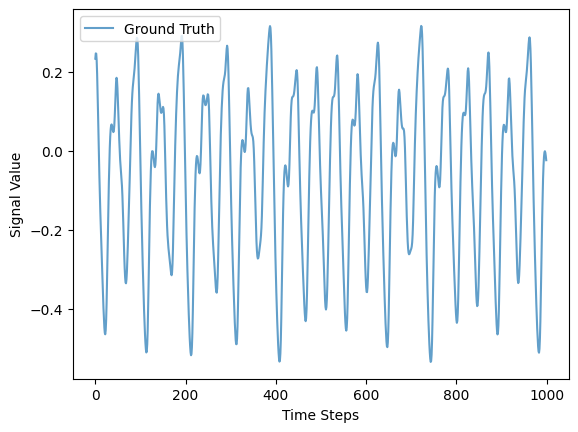

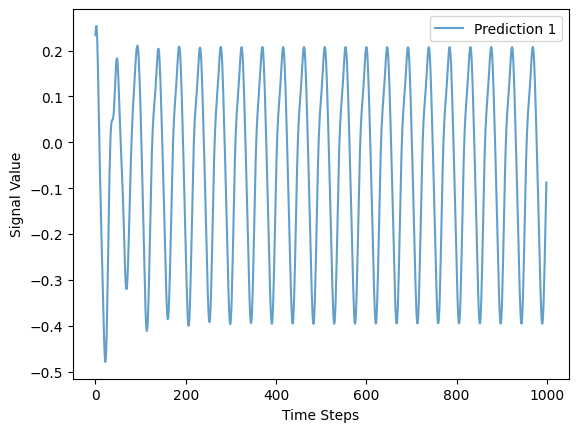

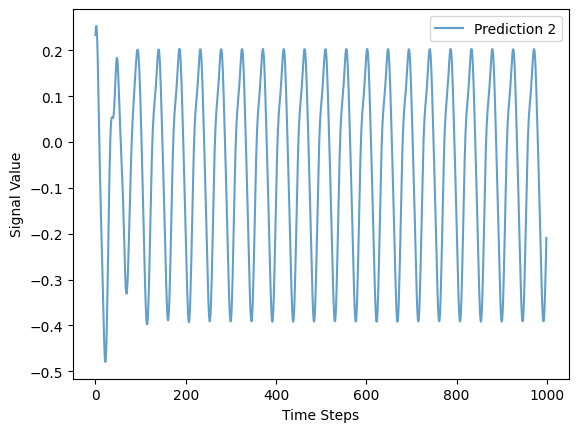

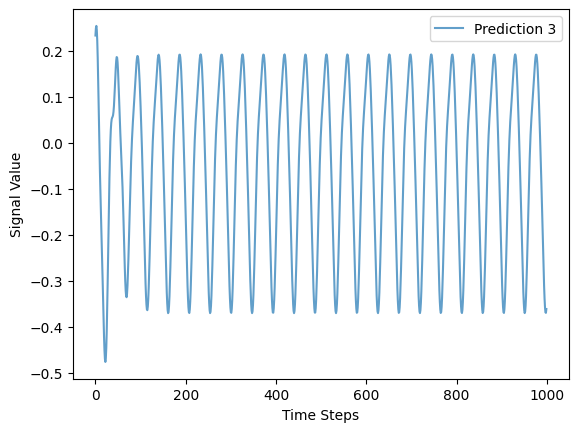

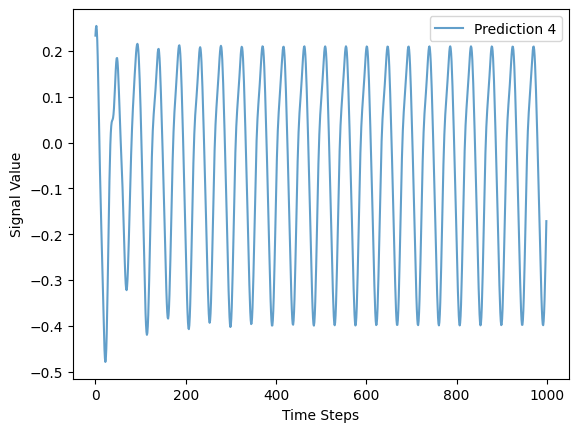

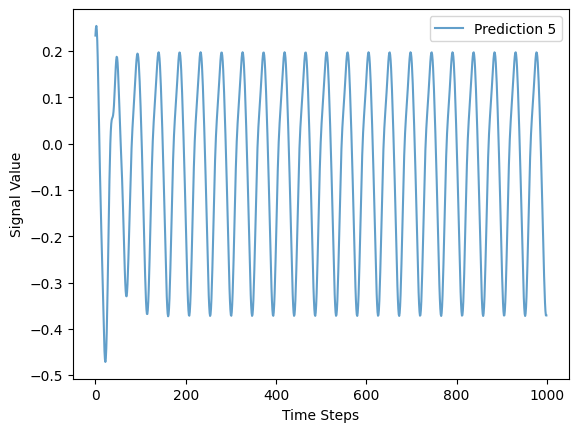

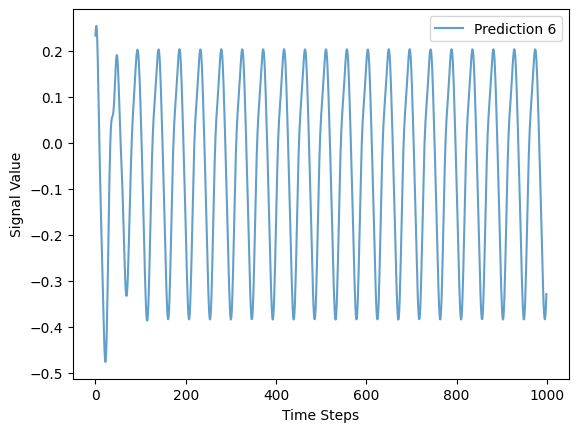

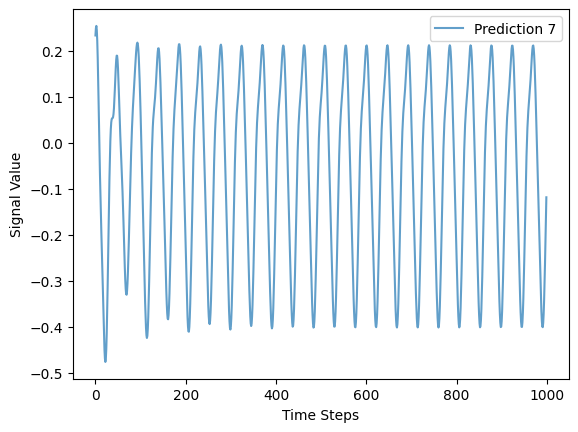

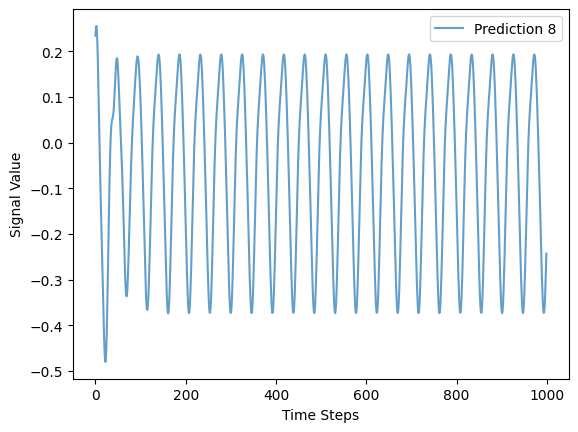

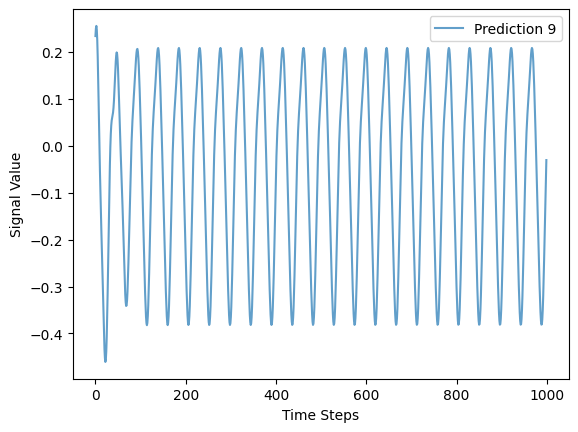

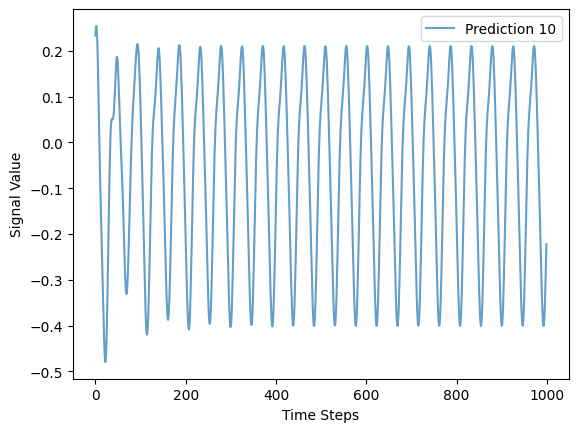

In [71]:
# Plot all predictions vs ground truth
plt.plot(targets_mg_test, label='Ground Truth', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()
plt.plot(preds_mg1, label='Prediction 1', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()
plt.plot(preds_mg2, label='Prediction 2', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()
plt.plot(preds_mg3, label='Prediction 3', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()
plt.plot(preds_mg4, label='Prediction 4', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()
plt.plot(preds_mg5, label='Prediction 5', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()
plt.plot(preds_mg6, label='Prediction 6', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()
plt.plot(preds_mg7, label='Prediction 7', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()
plt.plot(preds_mg8, label='Prediction 8', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()
plt.plot(preds_mg9, label='Prediction 9', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()
plt.plot(preds_mg10, label='Prediction 10', alpha=0.7)
plt.xlabel('Time Steps')
plt.ylabel('Signal Value')
plt.legend()
plt.show()

Task 4

In [106]:
def train_esn_sl(W, W_in, inp_train, targets_train, num_classes):
    n_train, series_len = inp_train.shape
    N = W.shape[0]

    states = np.zeros((n_train, N))
    for i in range(n_train):
        x = np.zeros((N, 1))
        seq = inp_train[i]
        for v in seq:
            u = np.array([[v], [1.0]])
            x = np.tanh(np.dot(W, x) + np.dot(W_in, u))
        states[i] = x[:, 0]

    Y = np.zeros((n_train, num_classes))
    labels = targets_train.astype(int).ravel()
    Y[np.arange(n_train), labels - 1] = 1.0

    sqrt_ridge = np.sqrt(1e-3)
    X_aug = np.vstack([states, sqrt_ridge * np.eye(N)])
    Y_aug = np.vstack([Y, np.zeros((N, num_classes))])
    W_out, *_ = np.linalg.lstsq(X_aug, Y_aug, rcond=None)

    return W_out


def predict_esn_sl(W, W_in, W_out, seq):
    N = W.shape[0]
    x = np.zeros((N, 1))

    for v in seq:
        u = np.array([[v], [1.0]])
        x = np.tanh(np.dot(W, x) + np.dot(W_in, u))

    scores = np.dot(x.T, W_out).ravel()
    pred_class = np.argmax(scores) + 1

    return pred_class, scores


In [103]:
# Set up resiovare and input weights for Swedish Leaf task
W_sl = create_reservoir(800, 0.99)
W_in_sl = create_input_weights(2, 800, 0.25)

# Extract data from tsv files
def load_swedish_leaf(train_path, test_path):
    train = np.loadtxt(train_path)
    test = np.loadtxt(test_path)

    targets_train = train[:, 0].astype(int)
    inp_train = train[:, 1:]

    targets_test  = test[:, 0].astype(int)
    inp_test = test[:, 1:]

    return inp_train, targets_train, inp_test, targets_test

sl_train_path = "data_task4/SwedishLeaf_TRAIN.tsv"
sl_test_path  = "data_task4/SwedishLeaf_TEST.tsv"

# Split data into trian and test sets
sl_inp_train, sl_targets_train, sl_inp_test, sl_targets_test = load_swedish_leaf(sl_train_path, sl_test_path)

# Train ESN for Swedish Leaf task
W_out_sl = train_esn_sl(W_sl, W_in_sl, sl_inp_train, sl_targets_train.reshape(-1, 1), 15)

In [104]:
# Evaluate ESN on test set
correct = 0
for i in range(sl_inp_test.shape[0]):
    pred, _ = predict_esn_sl(W_sl, W_in_sl, W_out_sl, sl_inp_test[i])
    if pred == sl_targets_test[i]:
        correct += 1

accuracy = correct / sl_inp_test.shape[0]
print("Accuracy:", accuracy)


Accuracy: 0.7248


In [107]:
random_state.seed(2)

W_sl2 = create_reservoir(800, 0.99)
W_in_sl2 = create_input_weights(2, 800, 0.25)
W_out_sl2 = train_esn_sl(W_sl2, W_in_sl2, sl_inp_train, sl_targets_train.reshape(-1, 1), 15)

correct2 = 0
for i in range(sl_inp_test.shape[0]):
    pred2, _ = predict_esn_sl(W_sl2, W_in_sl2, W_out_sl2, sl_inp_test[i])
    if pred2 == sl_targets_test[i]:
        correct2 += 1
accuracy2 = correct2 / sl_inp_test.shape[0]
print("Accuracy:", accuracy2)

Accuracy: 0.712


In [108]:
random_state.seed(3)

W_sl3 = create_reservoir(800, 0.99)
W_in_sl3 = create_input_weights(2, 800, 0.25)
W_out_sl3 = train_esn_sl(W_sl3, W_in_sl3, sl_inp_train, sl_targets_train.reshape(-1, 1), 15)

correct3 = 0
for i in range(sl_inp_test.shape[0]):
    pred3, _ = predict_esn_sl(W_sl3, W_in_sl3, W_out_sl3, sl_inp_test[i])
    if pred3 == sl_targets_test[i]:
        correct3 += 1
accuracy3 = correct3 / sl_inp_test.shape[0]
print("Accuracy:", accuracy3)

Accuracy: 0.7232


In [109]:
random_state.seed(4)

W_sl4 = create_reservoir(800, 0.99)
W_in_sl4 = create_input_weights(2, 800, 0.25)
W_out_sl4 = train_esn_sl(W_sl4, W_in_sl4, sl_inp_train, sl_targets_train.reshape(-1, 1), 15)

correct4 = 0
for i in range(sl_inp_test.shape[0]):
    pred4, _ = predict_esn_sl(W_sl4, W_in_sl4, W_out_sl4, sl_inp_test[i])
    if pred4 == sl_targets_test[i]:
        correct4 += 1
accuracy4 = correct4 / sl_inp_test.shape[0]
print("Accuracy:", accuracy4)

Accuracy: 0.7296


In [110]:
random_state.seed(5)

W_sl5 = create_reservoir(800, 0.99)
W_in_sl5 = create_input_weights(2, 800, 0.25)
W_out_sl5 = train_esn_sl(W_sl5, W_in_sl5, sl_inp_train, sl_targets_train.reshape(-1, 1), 15)

correct5 = 0
for i in range(sl_inp_test.shape[0]):
    pred5, _ = predict_esn_sl(W_sl5, W_in_sl5, W_out_sl5, sl_inp_test[i])
    if pred5 == sl_targets_test[i]:
        correct5 += 1
accuracy5 = correct5 / sl_inp_test.shape[0]
print("Accuracy:", accuracy5)

Accuracy: 0.7376


In [111]:
random_state.seed(6)

W_sl6 = create_reservoir(800, 0.99)
W_in_sl6 = create_input_weights(2, 800, 0.25)
W_out_sl6 = train_esn_sl(W_sl6, W_in_sl6, sl_inp_train, sl_targets_train.reshape(-1, 1), 15)

correct6 = 0
for i in range(sl_inp_test.shape[0]):
    pred6, _ = predict_esn_sl(W_sl6, W_in_sl6, W_out_sl6, sl_inp_test[i])
    if pred6 == sl_targets_test[i]:
        correct6 += 1
accuracy6 = correct6 / sl_inp_test.shape[0]
print("Accuracy:", accuracy6)

Accuracy: 0.7344


In [112]:
random_state.seed(7)

W_sl7 = create_reservoir(800, 0.99)
W_in_sl7 = create_input_weights(2, 800, 0.25)
W_out_sl7 = train_esn_sl(W_sl7, W_in_sl7, sl_inp_train, sl_targets_train.reshape(-1, 1), 15)

correct7 = 0
for i in range(sl_inp_test.shape[0]):
    pred7, _ = predict_esn_sl(W_sl7, W_in_sl7, W_out_sl7, sl_inp_test[i])
    if pred7 == sl_targets_test[i]:
        correct7 += 1
accuracy7 = correct7 / sl_inp_test.shape[0]
print("Accuracy:", accuracy7)

Accuracy: 0.7392


In [113]:
random_state.seed(8)

W_sl8 = create_reservoir(800, 0.99)
W_in_sl8= create_input_weights(2, 800, 0.25)
W_out_sl8 = train_esn_sl(W_sl8, W_in_sl8, sl_inp_train, sl_targets_train.reshape(-1, 1), 15)

correct8 = 0
for i in range(sl_inp_test.shape[0]):
    pred8, _ = predict_esn_sl(W_sl8, W_in_sl8, W_out_sl8, sl_inp_test[i])
    if pred8 == sl_targets_test[i]:
        correct8 += 1
accuracy8 = correct8 / sl_inp_test.shape[0]
print("Accuracy:", accuracy8)

Accuracy: 0.7168


In [114]:
random_state.seed(9)

W_sl9 = create_reservoir(800, 0.99)
W_in_sl9= create_input_weights(2, 800, 0.25)
W_out_sl9 = train_esn_sl(W_sl9, W_in_sl9, sl_inp_train, sl_targets_train.reshape(-1, 1), 15)

correct9 = 0
for i in range(sl_inp_test.shape[0]):
    pred9, _ = predict_esn_sl(W_sl9, W_in_sl9, W_out_sl9, sl_inp_test[i])
    if pred9 == sl_targets_test[i]:
        correct9 += 1
accuracy9 = correct9 / sl_inp_test.shape[0]
print("Accuracy:", accuracy9)

Accuracy: 0.7184


In [115]:
random_state.seed(10)

W_sl10 = create_reservoir(800, 0.99)
W_in_sl10 = create_input_weights(2, 800, 0.25)
W_out_sl10 = train_esn_sl(W_sl10, W_in_sl10, sl_inp_train, sl_targets_train.reshape(-1, 1), 15)

correct10 = 0
for i in range(sl_inp_test.shape[0]):
    pred10, _ = predict_esn_sl(W_sl10, W_in_sl10, W_out_sl10, sl_inp_test[i])
    if pred10 == sl_targets_test[i]:
        correct10 += 1

accuracy10 = correct10 / sl_inp_test.shape[0]
print("Accuracy:", accuracy10)

Accuracy: 0.7248


In [116]:
# Average accuracy over 10 runs
avg_accuracy = (accuracy + accuracy2 + accuracy3 + accuracy4 + accuracy5 + accuracy6 + accuracy7 + accuracy8 + accuracy9 + accuracy10) / 10
print("Average Accuracy over 10 runs:", avg_accuracy)

Average Accuracy over 10 runs: 0.7260800000000001
